In [1]:
from pathlib import Path
from astropy.io import fits
from astropy.table import Table
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt


# Update this path to point to a real FITS file on your system
fits_file_path = Path("/home/admin/main/ucsd-phys-139-final/data/tess_sector10/mastDownload/TESS/tess2019085135100-s0010-0000000001627709-0140-s/tess2019085135100-s0010-0000000001627709-0140-s_lc.fits")

if not fits_file_path.exists():
    raise FileNotFoundError(f"FITS file not found: {fits_file_path}")

with fits.open(fits_file_path) as hdul:
    print(f"Opened: {fits_file_path}")
    hdul.info()
    
    # Optionally, preview first ~20 header keys from the primary HDU
    primary_header = hdul[0].header
    print("\nPrimary header preview (first 20 keys):")
    for key in list(primary_header.keys())[:20]:
        print(f"{key}: {primary_header.get(key)}")



Opened: /home/admin/main/ucsd-phys-139-final/data/tess_sector10/mastDownload/TESS/tess2019085135100-s0010-0000000001627709-0140-s/tess2019085135100-s0010-0000000001627709-0140-s_lc.fits
Filename: /home/admin/main/ucsd-phys-139-final/data/tess_sector10/mastDownload/TESS/tess2019085135100-s0010-0000000001627709-0140-s/tess2019085135100-s0010-0000000001627709-0140-s_lc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   ()      
  1  LIGHTCURVE    1 BinTableHDU    167   18900R x 20C   [D, E, J, E, E, E, E, E, E, J, D, E, D, E, D, E, D, E, E, E]   
  2  APERTURE      1 ImageHDU        49   (11, 11)   int32   

Primary header preview (first 20 keys):
SIMPLE: True
BITPIX: 8
NAXIS: 0
EXTEND: True
NEXTEND: 2
EXTNAME: PRIMARY
EXTVER: 1
SIMDATA: False
ORIGIN: NASA/Ames
DATE: 2021-02-23
TSTART: 1569.442138688325
TSTOP: 1595.686437296261
DATE-OBS: 2019-03-26T22:35:31.599
DATE-END: 2019-04-22T04:27:18.998
CREATOR: 37300 LightCurveExporterPipe

In [2]:

with fits.open(fits_file_path) as hdul:
    print(f"Scanning {len(hdul)} HDU(s) for tables...")
    for idx, hdu in enumerate(hdul):
        hdu_type = type(hdu).__name__
        name = getattr(hdu, "name", f"HDU{idx}")
        print(f"\n=== HDU {idx} ({name}) - {hdu_type} ===")

        if hdu.data is None:
            print("No data in this HDU.")
            continue

        if isinstance(hdu, (fits.BinTableHDU, fits.TableHDU)):
            try:
                table = Table(hdu.data)
                print(f"Rows: {len(table)}, Columns: {len(table.colnames)}")
                if table.colnames:
                    preview_cols = table.colnames[:10]
                    print("Columns:", ", ".join(preview_cols) + (" ..." if len(table.colnames) > 10 else ""))
                print("First 5 rows:")
                print(table[:5])
            except Exception as e:
                print(f"Could not render table: {e}")
        else:
            data = hdu.data
            shape = getattr(data, "shape", None)
            dtype = getattr(data, "dtype", None)
            print(f"Non-table data. shape={shape}, dtype={dtype}")



Scanning 3 HDU(s) for tables...

=== HDU 0 (PRIMARY) - PrimaryHDU ===
No data in this HDU.

=== HDU 1 (LIGHTCURVE) - BinTableHDU ===
Rows: 18900, Columns: 20
Columns: TIME, TIMECORR, CADENCENO, SAP_FLUX, SAP_FLUX_ERR, SAP_BKG, SAP_BKG_ERR, PDCSAP_FLUX, PDCSAP_FLUX_ERR, QUALITY ...
First 5 rows:
       TIME          TIMECORR   CADENCENO ...  POS_CORR1  POS_CORR2 
------------------ ------------ --------- ... ----------- ----------
1569.4372774174503 0.0055482346    246223 ...         nan        nan
1569.4386663187836 0.0055482476    246224 ...         nan        nan
1569.4400552201168 0.0055482606    246225 ...         nan        nan
 1569.441444121917  0.005548274    246226 ...         nan        nan
1569.4428330232508  0.005548287    246227 ... 0.013827724 0.13938363

=== HDU 2 (APERTURE) - ImageHDU ===
Non-table data. shape=(11, 11), dtype=>i4



Found 2976 light-curve FITS files under /home/admin/main/ucsd-phys-139-final/data
Saved 2976 time/flux pairs to /home/admin/main/ucsd-phys-139-final/data/time_flux_pdcsap.pkl


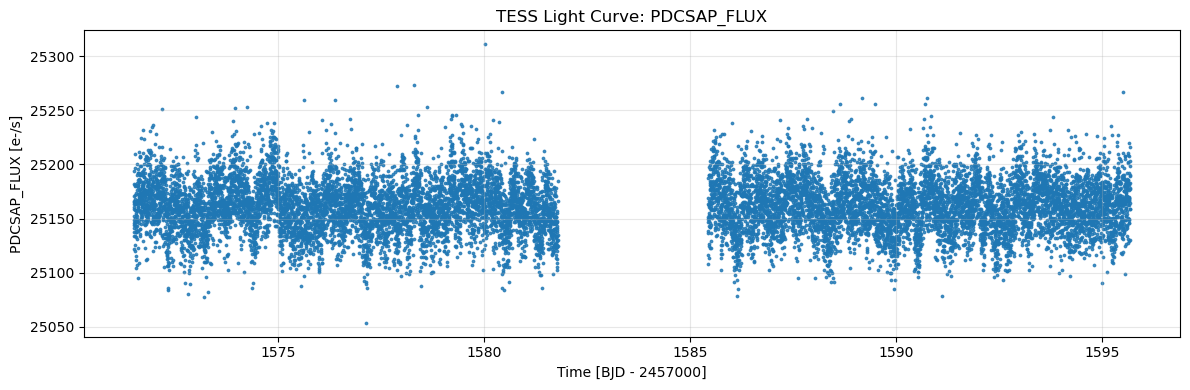

In [3]:
with fits.open(fits_file_path) as hdul:
    data = hdul[1].data  # LIGHTCURVE HDU
    time = data['TIME']
    flux = data['PDCSAP_FLUX']

mask = np.isfinite(time) & np.isfinite(flux)

plt.figure(figsize=(12, 4))
plt.scatter(time[mask], flux[mask], s=3, alpha=0.8)
plt.xlabel('Time [BJD - 2457000]')
plt.ylabel('PDCSAP_FLUX [e-/s]')
plt.title('TESS Light Curve: PDCSAP_FLUX')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# --- Build dataset: load all light-curve FITS and save (star_id, time, flux) triples ---
from pathlib import Path
import pickle

data_root = Path("/home/admin/main/ucsd-phys-139-final/data")
fits_files = sorted(data_root.rglob("*_lc.fits"))
print(f"\nFound {len(fits_files)} light-curve FITS files under {data_root}")

time_flux_list = []
for fp in fits_files:
    try:
        with fits.open(fp, memmap=True) as hdul_all:
            lc = hdul_all[1].data
            t = np.array(lc['TIME'], dtype=float)
            f = np.array(lc['PDCSAP_FLUX'], dtype=float)

            # Try to get TICID from header; fall back to filename pattern
            ticid = None
            try:
                ticid = hdul_all[0].header.get('TICID')
                if ticid is None:
                    ticid = hdul_all[1].header.get('TICID')
            except Exception:
                ticid = None

            if ticid is None:
                parts = fp.name.split('-')
                ticid = parts[2] if len(parts) > 2 else fp.stem

            star_id = str(ticid)
            time_flux_list.append((star_id, t, f))
    except Exception as e:
        print(f"Skipping {fp}: {e}")

out_pkl = Path("/home/admin/main/ucsd-phys-139-final/data/time_flux_pdcsap.pkl")
out_pkl.parent.mkdir(parents=True, exist_ok=True)
with out_pkl.open("wb") as f:
    pickle.dump(time_flux_list, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved {len(time_flux_list)} time/flux pairs to {out_pkl}")

